# Overtake Probability Model v6 — IP07 Broad Scenario Dataset

**Data version:** `data/v6`  
**Train split:** `2022-2024`  
**Holdout test:** `2025`  
**Primary target:** `label` = `overtake_within_3`

This notebook trains a compact v6 baseline and keeps only the main training and holdout evaluation views.

## Why v6 is different

- Positives come from the wider overtake extraction implemented in `pipeline_testing.ipynb` and ported into `pipeline/v6_pipeline.py`.
- Candidate rows are broader adjacent attacker-defender scenarios within `3.0s`, not the old narrow battle framing.
- The primary label is `within_3`, so v6 should be read as a broader scenario model rather than a pure next-lap battle model.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data" / "v6"
TRAIN_YEARS = [2022, 2023, 2024]
TEST_YEARS = [2025]
TARGET = "label"


In [2]:
def load_years(years):
    frames = []
    for year in years:
        path = DATA_DIR / f"scenarios_{year}.csv"
        if not path.exists():
            print(f"WARNING: missing {path}")
            continue
        frame = pd.read_csv(path)
        frame["source_year"] = year
        frames.append(frame)
        print(f"{year}: {len(frame):,} rows | positive rate={frame[TARGET].mean():.2%}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("Training data")
df_train = load_years(TRAIN_YEARS)
print()
print("Holdout data")
df_test = load_years(TEST_YEARS)

summary = pd.concat([
    df_train.assign(split="train").groupby("source_year", as_index=False)[TARGET].agg(rows="size", positive_rate="mean").rename(columns={"source_year": "year"}),
    df_test.assign(split="test").groupby("source_year", as_index=False)[TARGET].agg(rows="size", positive_rate="mean").rename(columns={"source_year": "year"}),
], ignore_index=True)
print(summary.to_string(index=False))
print("\nInterpretation:")
print("- The split summary shows that v6 uses a much larger candidate universe than the older battle notebooks.")
print("- The lower 2025 positive rate is a reminder that v6 holdout evaluation includes season shift, not just raw model fit.")


Training data
2022: 11,380 rows | positive rate=11.04%
2023: 12,334 rows | positive rate=10.45%


2024: 13,229 rows | positive rate=9.27%

Holdout data
2025: 14,565 rows | positive rate=8.20%
 year  rows  positive_rate
 2022 11380       0.110369
 2023 12334       0.104508
 2024 13229       0.092675
 2025 14565       0.081977

Interpretation:
- The split summary shows that v6 uses a much larger candidate universe than the older battle notebooks.
- The lower 2025 positive rate is a reminder that v6 holdout evaluation includes season shift, not just raw model fit.


In [3]:
# Keep the scenario framing aligned with the positive extraction by dropping pit-stop rows.
df_train = df_train[~df_train["pit_stop_involved"].astype(bool)].copy()
df_test = df_test[~df_test["pit_stop_involved"].astype(bool)].copy()

for frame in (df_train, df_test):
    bool_cols = frame.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        frame[col] = frame[col].astype(int)

EXCLUDE = {
    TARGET,
    "overtake_next_lap",
    "overtake_within_2",
    "overtake_within_3",
    "race_name",
    "event_date",
    "attacker",
    "defender",
    "candidate_gap_threshold",
    "source_year",
}

FEATURES = [c for c in df_train.columns if c not in EXCLUDE]
CAT_COLS = [c for c in FEATURES if df_train[c].dtype == "object"]
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]

X_train = df_train[FEATURES].copy()
y_train = df_train[TARGET].astype(int)
X_test = df_test[FEATURES].copy()
y_test = df_test[TARGET].astype(int)

print(f"Train rows after pit filter: {len(X_train):,}")
print(f"Test rows after pit filter:  {len(X_test):,}")
print(f"Train positive rate: {y_train.mean():.2%}")
print(f"Test positive rate:  {y_test.mean():.2%}")
print(f"Features: {len(FEATURES)} | numeric={len(NUM_COLS)} | categorical={len(CAT_COLS)}")


Train rows after pit filter: 35,049
Test rows after pit filter:  13,883
Train positive rate: 10.76%
Test positive rate:  8.60%
Features: 98 | numeric=89 | categorical=9


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
        ("num", "passthrough", NUM_COLS),
    ]
)

pos = int(y_train.sum())
neg = int(len(y_train) - pos)
scale_pos_weight = neg / max(pos, 1)

model = XGBClassifier(
    n_estimators=350,
    max_depth=5,
    learning_rate=0.035,
    min_child_weight=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.02,
    reg_lambda=1.5,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
)

pipeline = Pipeline([
    ("pre", preprocessor),
    ("model", model),
])

pipeline.fit(X_train, y_train)
test_proba = pipeline.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame(
    {
        "metric": ["roc_auc", "pr_auc", "brier"],
        "value": [
            roc_auc_score(y_test, test_proba),
            average_precision_score(y_test, test_proba),
            brier_score_loss(y_test, test_proba),
        ],
    }
)
print(metrics.to_string(index=False))
print("\nInterpretation:")
print("- These holdout metrics summarize how well the broader v6 scenario score ranks and calibrates future overtakes in 2025.")
print("- PR-AUC is especially important here because the label is still imbalanced even though v6 is broader than v1-v5.")


 metric    value
roc_auc 0.910956
 pr_auc 0.598446
  brier 0.098380

Interpretation:
- These holdout metrics summarize how well the broader v6 scenario score ranks and calibrates future overtakes in 2025.
- PR-AUC is especially important here because the label is still imbalanced even though v6 is broader than v1-v5.


Best F1 threshold on 2025 PR curve: 0.721
Confusion matrix [ [TN, FP], [FN, TP] ]
[[12045   644]
 [  458   736]]


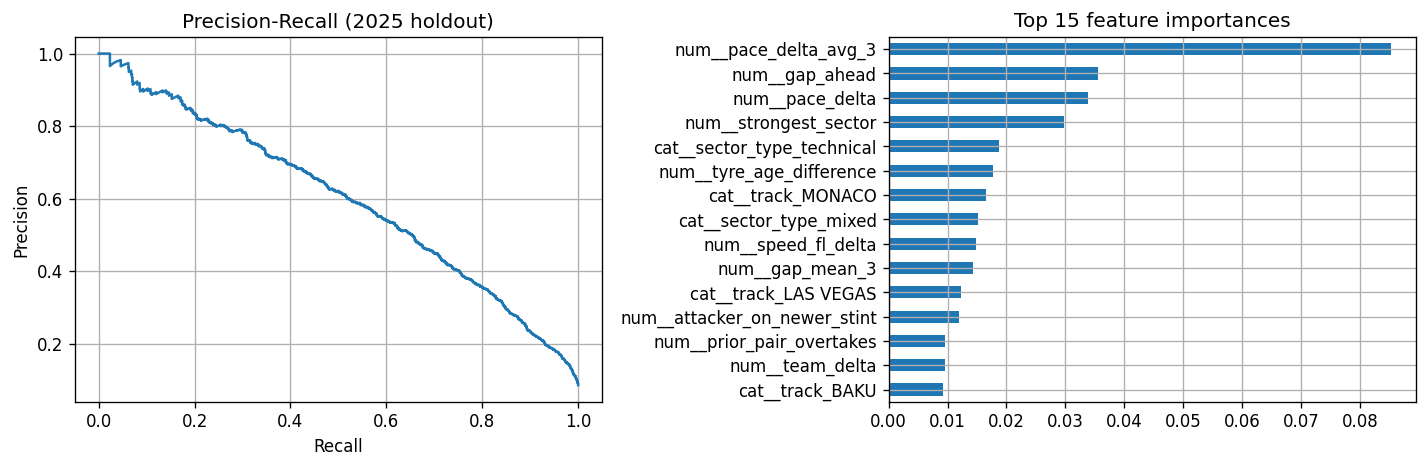

                race_name  rows  actual_positive_rate  predicted_positive_rate  mean_probability
     Abu Dhabi Grand Prix   677              0.149188                 0.162482          0.313448
     São Paulo Grand Prix   640              0.134375                 0.189062          0.335543
      Austrian Grand Prix   471              0.123142                 0.116773          0.244473
 Saudi Arabian Grand Prix   452              0.121681                 0.139381          0.259389
Emilia Romagna Grand Prix   720              0.115278                 0.123611          0.258321
      Canadian Grand Prix   724              0.109116                 0.099448          0.234792
       Spanish Grand Prix   514              0.108949                 0.118677          0.253057
       Bahrain Grand Prix   687              0.104803                 0.126638          0.285505
   Mexico City Grand Prix   581              0.103270                 0.079174          0.232615
         Miami Grand Prix   48

In [5]:
precision, recall, thresholds = precision_recall_curve(y_test, test_proba)
f1_scores = (2 * precision[:-1] * recall[:-1]) / np.clip(precision[:-1] + recall[:-1], 1e-9, None)
best_idx = int(np.nanargmax(f1_scores))
best_threshold = float(thresholds[best_idx])
test_pred = (test_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

print(f"Best F1 threshold on 2025 PR curve: {best_threshold:.3f}")
print("Confusion matrix [ [TN, FP], [FN, TP] ]")
print(cm)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(recall, precision)
ax[0].set_title("Precision-Recall (2025 holdout)")
ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")

feature_names = pipeline.named_steps["pre"].get_feature_names_out()
importance = pd.Series(
    pipeline.named_steps["model"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False).head(15)
importance.sort_values().plot(kind="barh", ax=ax[1])
ax[1].set_title("Top 15 feature importances")
plt.tight_layout()
plt.show()

race_analysis = (
    pd.DataFrame({"race_name": df_test["race_name"].values, "actual": y_test.values, "pred": test_pred, "proba": test_proba})
    .groupby("race_name", as_index=False)
    .agg(rows=("actual", "size"), actual_positive_rate=("actual", "mean"), predicted_positive_rate=("pred", "mean"), mean_probability=("proba", "mean"))
    .sort_values("actual_positive_rate", ascending=False)
)
print(race_analysis.head(10).to_string(index=False))
print("\nInterpretation:")
print("- The thresholded confusion matrix gives one operational view, but v6 should still be interpreted as a within-3-laps scenario model rather than a pure next-lap classifier.")
print("- The feature-importance and per-race tables help show whether the model is driven by plausible race-dynamics features and whether some circuits are systematically easier or harder.")


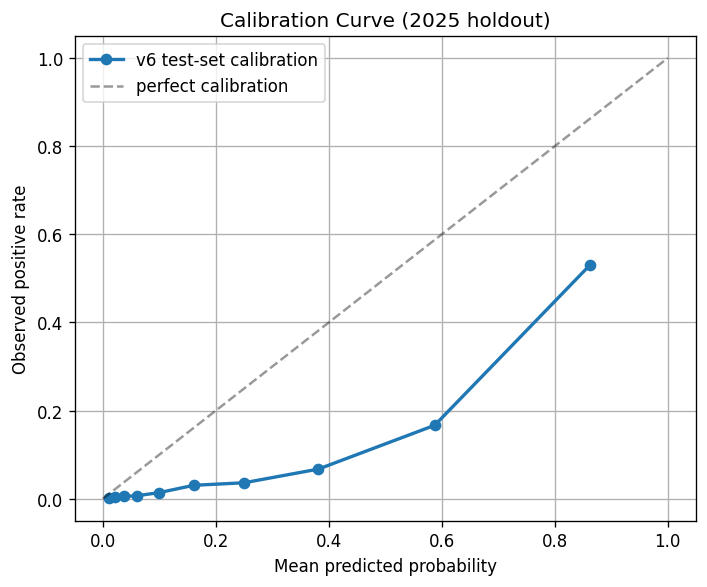

 bin  mean_predicted_probability  observed_positive_rate     gap
   1                      0.0102                  0.0014 -0.0087
   2                      0.0217                  0.0029 -0.0189
   3                      0.0367                  0.0050 -0.0316
   4                      0.0598                  0.0065 -0.0533
   5                      0.0997                  0.0137 -0.0860
   6                      0.1606                  0.0303 -0.1304
   7                      0.2499                  0.0360 -0.2139
   8                      0.3813                  0.0670 -0.3143
   9                      0.5873                  0.1664 -0.4209
  10                      0.8626                  0.5306 -0.3320

Interpretation:
- This curve checks whether v6 probabilities on the unseen 2025 season are numerically trustworthy, not just well ranked.
- Points above the diagonal indicate the model is conservative in that score range, while points below it indicate overconfidence.
- For v6 this m

In [6]:
from sklearn.calibration import calibration_curve

fraction_pos, mean_pred = calibration_curve(y_test, test_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mean_pred, fraction_pos, marker="o", linewidth=2, label="v6 test-set calibration")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfect calibration")
ax.set_title("Calibration Curve (2025 holdout)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive rate")
ax.legend()
plt.tight_layout()
plt.show()

calibration_table = pd.DataFrame(
    {
        "bin": range(1, len(mean_pred) + 1),
        "mean_predicted_probability": mean_pred,
        "observed_positive_rate": fraction_pos,
        "gap": fraction_pos - mean_pred,
    }
)
print(calibration_table.round(4).to_string(index=False))
print("\nInterpretation:")
print("- This curve checks whether v6 probabilities on the unseen 2025 season are numerically trustworthy, not just well ranked.")
print("- Points above the diagonal indicate the model is conservative in that score range, while points below it indicate overconfidence.")
print("- For v6 this matters because the score is meant to support broader within-3-laps scenario triage, so calibration affects how literally users can read the predicted probability.")

In [7]:
import json
import joblib

ARTIFACTS_DIR = ROOT / "models" / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

trained_feature_names = list(
    pipeline.named_steps["pre"].get_feature_names_out()
)

metrics_map = {row["metric"]: float(row["value"]) for _, row in metrics.iterrows()}

meta = {
    "model": "XGBoost",
    "task": "overtake_within_3",
    "data_version": "v6",
    "years_train": sorted(df_train["year"].dropna().astype(int).unique().tolist()),
    "holdout_years": sorted(df_test["year"].dropna().astype(int).unique().tolist()),
    "threshold": float(best_threshold),
    "features": CAT_COLS + NUM_COLS,
    "cat_cols": CAT_COLS,
    "num_cols": NUM_COLS,
    "trained_feature_names": trained_feature_names,
    "train_shape": [int(df_train.shape[0]), int(df_train.shape[1])],
    "test_shape": [int(df_test.shape[0]), int(df_test.shape[1])],
    "metrics": {
        "holdout_roc_auc": metrics_map.get("roc_auc"),
        "holdout_pr_auc": metrics_map.get("pr_auc"),
        "holdout_brier": metrics_map.get("brier"),
        "holdout_positive_rate": float(y_test.mean()),
    },
}

model_path = ARTIFACTS_DIR / "overtake_model_v6.pkl"
meta_path = ARTIFACTS_DIR / "overtake_model_v6_meta.json"

joblib.dump(pipeline, model_path)
meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"Saved model to {model_path}")
print(f"Saved metadata to {meta_path}")

Saved model to /Users/aminnami/Desktop/hamid/ai_in_industry/formula1-overtake-prediction/models/artifacts/overtake_model_v6.pkl
Saved metadata to /Users/aminnami/Desktop/hamid/ai_in_industry/formula1-overtake-prediction/models/artifacts/overtake_model_v6_meta.json
